# Lab 04 — Hybrid retrieval (interactive)

BM25 + dense + RRF, scored on exact-token vs semantic queries.

**Before running:** `./tunnel.sh`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "04_hybrid_retrieval")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
print("labs root:", LABS)

labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs


## Run all three retrievers

In [2]:
import hybrid
from shared.embedder import get_embedder

emb = get_embedder("tei")
retrievers, rows = hybrid.evaluate_all(emb)
for r in rows:
    print(r)

{'retriever': 'bm25', 'group': 'exact', 'hit@1': 1.0, 'hit@3': 1.0, 'mrr': 1.0}
{'retriever': 'bm25', 'group': 'semantic', 'hit@1': 0.75, 'hit@3': 0.75, 'mrr': 0.775}
{'retriever': 'dense', 'group': 'exact', 'hit@1': 1.0, 'hit@3': 1.0, 'mrr': 1.0}
{'retriever': 'dense', 'group': 'semantic', 'hit@1': 1.0, 'hit@3': 1.0, 'mrr': 1.0}
{'retriever': 'hybrid', 'group': 'exact', 'hit@1': 1.0, 'hit@3': 1.0, 'mrr': 1.0}
{'retriever': 'hybrid', 'group': 'semantic', 'hit@1': 0.75, 'hit@3': 1.0, 'mrr': 0.8333333333333334}


## Where each retriever wins (hit@1)
BM25 owns exact tokens; dense owns paraphrases; hybrid covers both.

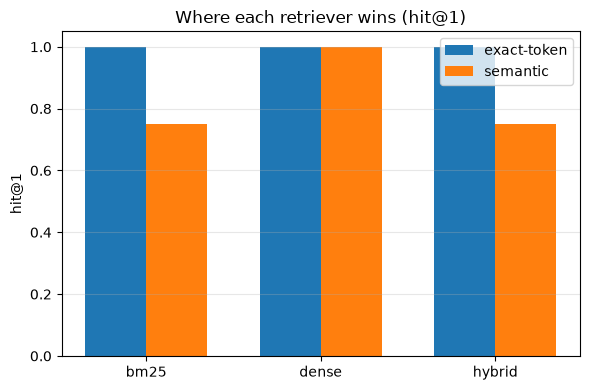

In [3]:
import numpy as np
import matplotlib.pyplot as plt

names = ["bm25", "dense", "hybrid"]
exact = [next(r["hit@1"] for r in rows if r["retriever"] == n and r["group"] == "exact") for n in names]
sem = [next(r["hit@1"] for r in rows if r["retriever"] == n and r["group"] == "semantic") for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w / 2, exact, w, label="exact-token")
ax.bar(x + w / 2, sem, w, label="semantic")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("hit@1")
ax.set_ylim(0, 1.05)
ax.set_title("Where each retriever wins (hit@1)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## The money example: `ERR_4521`
Dense ranks the near-identical sibling `err_4522` first; BM25 nails the exact code; hybrid recovers the correct #1.

In [4]:
q = "What does fault ERR_4521 indicate?"
for name, rk in retrievers.items():
    print(f"{name:6}: {rk[q][:3]}")

bm25  : ['err_4521.md', 'err_7788.md', 'err_4599.md']
dense : ['err_4521.md', 'err_7788.md', 'err_7789.md']
hybrid: ['err_4521.md', 'err_7788.md', 'err_7789.md']
